<a href="https://colab.research.google.com/github/stephenwacha743-maker/GEO2102-GROUP2-HOSTEL-ASSIGNMENT/blob/main/STATISITICAL_ANALYSIS_COURSEWORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
np.random.seed(42)

In [3]:
num_samples = 150

In [4]:
baseline_length_km = np.random.uniform(0.5, 25.0, num_samples)  # Distance from base (0.5 to 25 km)
pdop = np.random.uniform(1.2, 4.5, num_samples)


In [5]:
error_e = np.random.normal(0, 0.005, num_samples) + (baseline_length_km * 0.0008) + (pdop * 0.002)
error_n = np.random.normal(0, 0.005, num_samples) + (baseline_length_km * 0.0007) + (pdop * 0.0018)
error_h = np.random.normal(0, 0.010, num_samples) + (baseline_length_km * 0.0015) + (pdop * 0.003)


In [6]:
error_3d = np.sqrt(error_e**2 + error_n**2 + error_h**2)

In [7]:
df = pd.DataFrame({
    'Baseline_km': baseline_length_km,
    'PDOP': pdop,
    'Error_E_m': error_e,
    'Error_N_m': error_n,
    'Error_H_m': error_h,
    'Error_3D_m': error_3d
})


In [8]:
print("--- DESCRIPTIVE STATISTICS ---")
print(df.describe().T[['mean', 'std', 'min', '50%', 'max']])
print("\n" + "="*50 + "\n")


--- DESCRIPTIVE STATISTICS ---
                  mean       std       min        50%        max
Baseline_km  12.085735  7.265004  0.635292  11.478725  24.678730
PDOP          2.907823  0.961659  1.216703   3.034803   4.467178
Error_E_m     0.015791  0.007935  0.000753   0.015415   0.033971
Error_N_m     0.013245  0.008142 -0.003887   0.012692   0.032057
Error_H_m     0.026801  0.013815 -0.002101   0.025372   0.060670
Error_3D_m    0.035138  0.015096  0.007170   0.034643   0.075015




In [9]:
pearson_corr = df.corr(method='pearson')
print("--- PEARSON CORRELATION MATRIX ---")
print(pearson_corr)
print("\n" + "="*50 + "\n")


--- PEARSON CORRELATION MATRIX ---
             Baseline_km      PDOP  Error_E_m  Error_N_m  Error_H_m  \
Baseline_km     1.000000  0.035691   0.788265   0.727687   0.653097   
PDOP            0.035691  1.000000   0.227140   0.291393   0.186735   
Error_E_m       0.788265  0.227140   1.000000   0.657916   0.542627   
Error_N_m       0.727687  0.291393   0.657916   1.000000   0.513950   
Error_H_m       0.653097  0.186735   0.542627   0.513950   1.000000   
Error_3D_m      0.802125  0.250598   0.756258   0.728860   0.939006   

             Error_3D_m  
Baseline_km    0.802125  
PDOP           0.250598  
Error_E_m      0.756258  
Error_N_m      0.728860  
Error_H_m      0.939006  
Error_3D_m     1.000000  




In [10]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Baseline_km'], df['Error_3D_m'])
print("--- LINEAR REGRESSION RESULTS (Baseline vs 3D Error) ---")
print(f"Slope (m/km)    : {slope:.6f}")
print(f"Intercept (m)   : {intercept:.6f}")
print(f"R-squared (R²)  : {r_value**2:.4f}")
print(f"p-value         : {p_value:.4e}")
print(f"Standard Error  : {std_err:.6f}")



--- LINEAR REGRESSION RESULTS (Baseline vs 3D Error) ---
Slope (m/km)    : 0.001667
Intercept (m)   : 0.014994
R-squared (R²)  : 0.6434
p-value         : 5.9053e-35
Standard Error  : 0.000102


Text(0.5, 1.0, 'Correlation Matrix of Survey Variables')

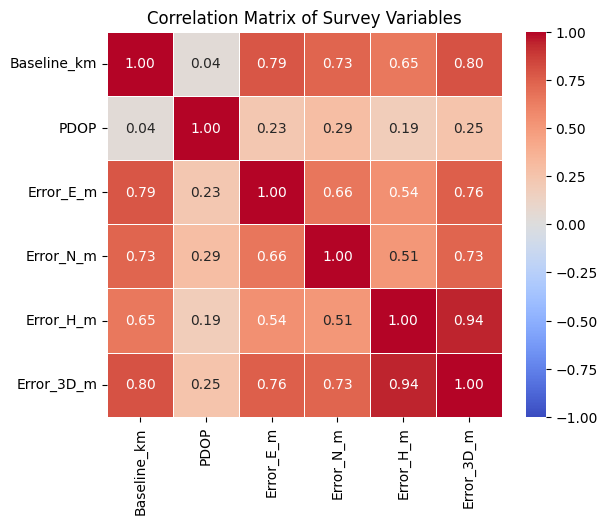

In [11]:
plt.figure(figsize=(14, 5))

# Plot 1: Correlation Matrix Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Survey Variables')



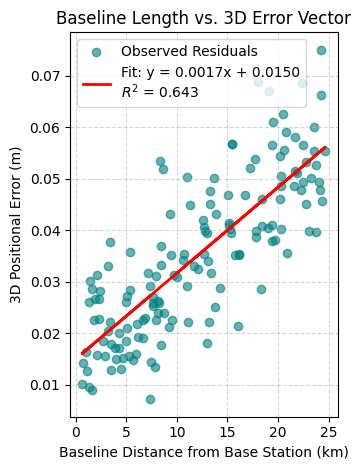

In [12]:
plt.subplot(1, 2, 2)
plt.scatter(df['Baseline_km'], df['Error_3D_m'], color='teal', alpha=0.6, label='Observed Residuals')
plt.plot(df['Baseline_km'], intercept + slope * df['Baseline_km'], color='red', linewidth=2,
         label=f'Fit: y = {slope:.4f}x + {intercept:.4f}\n$R^2$ = {r_value**2:.3f}')
plt.xlabel('Baseline Distance from Base Station (km)')
plt.ylabel('3D Positional Error (m)')
plt.title('Baseline Length vs. 3D Error Vector')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


In [37]:
import numpy as np
from scipy import stats

def calculate_pearson_correlation(x, y, alternative='two-sided'):
    """
    Calculates Pearson correlation coefficient and p-value for 1-tailed or 2-tailed tests.

    Parameters:
    -----------
    x, y : array-like
        Numeric data arrays of equal length.
    alternative : str, optional
        - 'two-sided': Two-tailed hypothesis test (H1: r != 0)
        - 'greater'  : One-tailed test for positive correlation (H1: r > 0)
        - 'less'     : One-tailed test for negative correlation (H1: r < 0)

    Returns:
    --------
    r : float
        Pearson correlation coefficient.
    p_val : float
        Corresponding p-value for the selected hypothesis test.
    """
    # scipy.stats.pearsonr natively supports alternative parameter (scipy >= 1.9.0)
    res = stats.pearsonr(x, y, alternative=alternative)
    return res.statistic, res.pvalue

In [39]:
# @title Default title text
if __name__ == "__main__":
    # Test the pearson correlation function on the dataset
    r, p_val = calculate_pearson_correlation(df['Baseline_km'], df['Error_3D_m'], alternative='greater')
    print("--- TEST PEARSON CORRELATION FUNCTION ---")
    print(f"Correlation (r) : {r:.4f}")
    print(f"p-value         : {p_val:.4e}")


--- TEST PEARSON CORRELATION FUNCTION ---
Correlation (r) : 0.8021
p-value         : 2.9526e-35


In [41]:
np.random.seed(42)
baseline_km = np.array([1.2, 2.5, 3.8, 5.1, 7.0, 8.5, 10.2, 12.0, 15.1, 18.0])
error_3d_m  = np.array([0.008, 0.011, 0.013, 0.015, 0.019, 0.022, 0.025, 0.028, 0.034, 0.039])

In [42]:
r_two, p_two = calculate_pearson_correlation(baseline_km, error_3d_m, alternative='two-sided')

In [43]:
r_one_greater, p_one_greater = calculate_pearson_correlation(baseline_km, error_3d_m, alternative='greater')

In [44]:
r_one_less, p_one_less = calculate_pearson_correlation(baseline_km, error_3d_m, alternative='less')

In [46]:
print(f"Pearson Correlation Coefficient (r) : {r_two:.4f}\n")
print("--- HYPOTHESIS TESTING RESULTS ---")
print(f"Two-Tailed p-value (r != 0)         : {p_two:.4e}")
print(f"One-Tailed p-value (r > 0, Positive) : {p_one_greater:.4e}")
print(f"One-Tailed p-value (r < 0, Negative) : {p_one_less:.4e}")

Pearson Correlation Coefficient (r) : 0.9997

--- HYPOTHESIS TESTING RESULTS ---
Two-Tailed p-value (r != 0)         : 4.2664e-14
One-Tailed p-value (r > 0, Positive) : 2.1332e-14
One-Tailed p-value (r < 0, Negative) : 1.0000e+00


In [48]:
alpha = 0.05
if p_two < alpha:
    print(f"\nVerdict: Reject H0 at alpha={alpha}. The correlation is statistically significant.")
else:
    print(f"\nVerdict: Fail to reject H0 at alpha={alpha}. No significant linear correlation.")


Verdict: Reject H0 at alpha=0.05. The correlation is statistically significant.


In [49]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
np.random.seed(42)
baseline_km = np.array([1.2, 2.5, 3.8, 5.1, 7.0, 8.5, 10.2, 12.0, 15.1, 18.0])
error_3d_m  = np.array([0.008, 0.011, 0.013, 0.015, 0.019, 0.022, 0.025, 0.028, 0.034, 0.039])

In [51]:
df = pd.DataFrame({
    'Baseline_km': baseline_km,
    'Error_3D_m': error_3d_m
})

In [52]:
r_val, p_two = stats.pearsonr(df['Baseline_km'], df['Error_3D_m'], alternative='two-sided')

In [53]:
_, p_one_greater = stats.pearsonr(df['Baseline_km'], df['Error_3D_m'], alternative='greater')

In [54]:
slope, intercept, _, _, std_err = stats.linregress(df['Baseline_km'], df['Error_3D_m'])

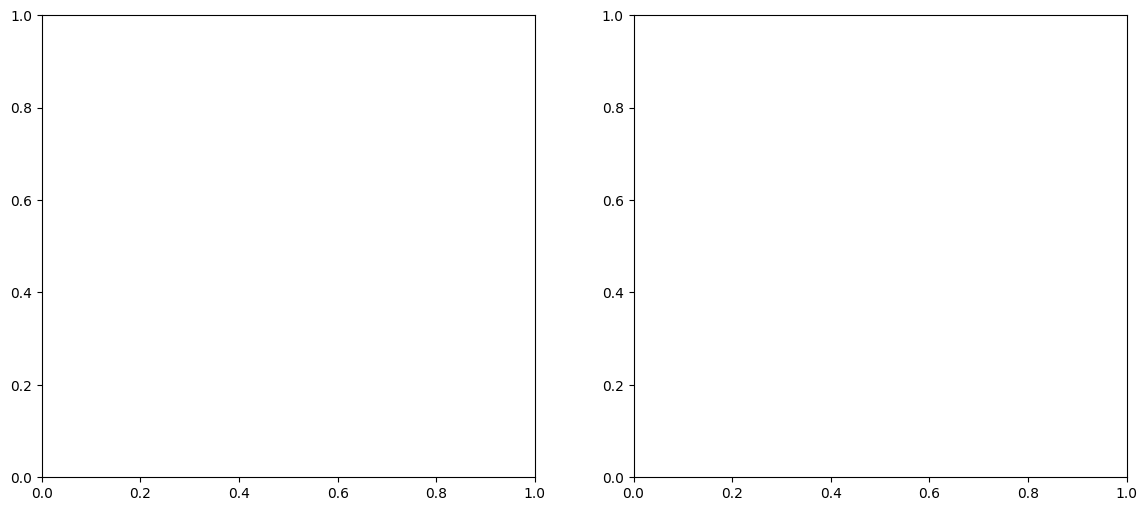

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

In [56]:
corr_matrix = df.corr(method='pearson')
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt=".3f",
    linewidths=1,
    cbar=True,
    ax=axes[0]
)
axes[0].set_title('Pearson Correlation Heatmap', fontsize=12, fontweight='bold')

Text(0.5, 1.0, 'Pearson Correlation Heatmap')

In [57]:
axes[1].scatter(
    df['Baseline_km'],
    df['Error_3D_m'],
    color='darkcyan',
    s=60,
    edgecolor='k',
    zorder=3,
    label='Observed Data'
)

In [58]:
x_vals = np.linspace(df['Baseline_km'].min(), df['Baseline_km'].max(), 100)
y_vals = intercept + slope * x_vals
axes[1].plot(
    x_vals,
    y_vals,
    color='crimson',
    linewidth=2,
    linestyle='--',
    label=f'Linear Fit (y = {slope:.4f}x + {intercept:.4f})'
)

In [59]:
stats_text = (
    f"Pearson $r$ = {r_val:.4f}\n"
    f"$R^2$ = {r_val**2:.4f}\n"
    f"Two-Tailed $p$ = {p_two:.2e}\n"
    f"One-Tailed $p$ ($r>0$) = {p_one_greater:.2e}"
)
axes[1].text(
    0.05, 0.95, stats_text,
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', alpha=0.9, edgecolor='gray')
)

axes[1].set_xlabel('Baseline Distance (km)', fontsize=11)
axes[1].set_ylabel('3D Positional Error (m)', fontsize=11)
axes[1].set_title('Baseline Length vs. 3D Error Analysis', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [30]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(101)
sample_size = 200


In [31]:
residuals = np.random.normal(loc=0.002, scale=0.012, size=sample_size) + np.random.exponential(scale=0.003, size=sample_size)

In [32]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)
ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))

print("--- RESIDUAL NORMALITY DIAGNOSTIC TESTS ---")
print(f"Mean Residual         : {np.mean(residuals):.5f} m")
print(f"Standard Deviation    : {np.std(residuals):.5f} m")
print(f"Shapiro-Wilk Test     : W = {shapiro_stat:.4f}, p-value = {shapiro_p:.4e}")
print(f"Kolmogorov-Smirnov    : D = {ks_stat:.4f}, p-value = {ks_p:.4e}")

if shapiro_p > 0.05:
    print("Verdict: Residuals follow a Normal Distribution (Fail to reject H0 at 5% alpha).")
else:
    print("Verdict: Residuals deviate significantly from a Normal Distribution (Reject H0 at 5% alpha).")



--- RESIDUAL NORMALITY DIAGNOSTIC TESTS ---
Mean Residual         : 0.00574 m
Standard Deviation    : 0.01304 m
Shapiro-Wilk Test     : W = 0.9943, p-value = 6.4166e-01
Kolmogorov-Smirnov    : D = 0.0461, p-value = 7.7063e-01
Verdict: Residuals follow a Normal Distribution (Fail to reject H0 at 5% alpha).


In [33]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Axes: ylabel='Density'>

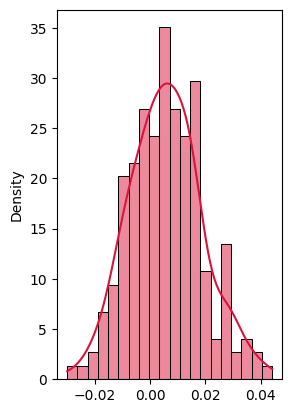

In [34]:
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='crimson', bins=20, stat="density")


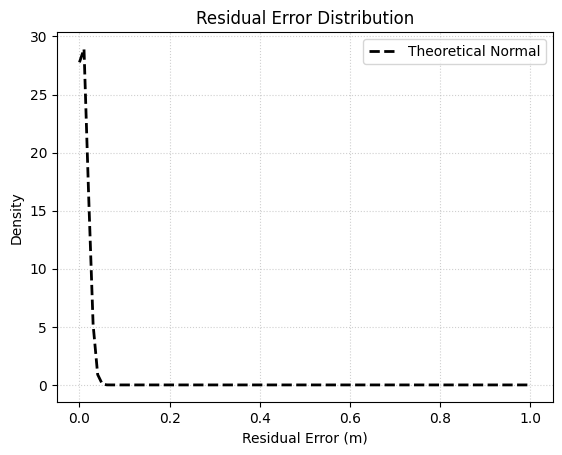

In [35]:
xmin, xmax = plt.xlim()
x_axis = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x_axis, np.mean(residuals), np.std(residuals))
plt.plot(x_axis, p, 'k--', linewidth=2, label='Theoretical Normal')

plt.title('Residual Error Distribution')
plt.xlabel('Residual Error (m)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)


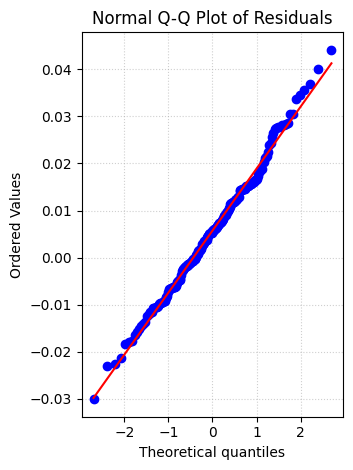

In [36]:
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot of Residuals')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
